In [22]:
#Importing Libraries
import os
import time
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── SCIKIT-LEARN: MODEL SELECTION ─────────────────────
from sklearn.model_selection import train_test_split

# ── SCIKIT-LEARN: PREPROCESSING ───────────────────────
from sklearn.preprocessing import StandardScaler

# ── SCIKIT-LEARN: REGRESSION MODELS ───────────────────
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

# ── SCIKIT-LEARN: CLASSIFICATION MODELS ───────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC

from sklearn.calibration import CalibratedClassifierCV

# ── XGBOOST ───────────────────────────────────────────
from xgboost import XGBClassifier
from xgboost import XGBRegressor

# ── LIGHTGBM ──────────────────────────────────────────
import lightgbm as lgb

# ── METRICS: REGRESSION ───────────────────────────────
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

# ── METRICS: CLASSIFICATION ───────────────────────────
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# ── VERSION CHECK ─────────────────────────────────────
import sklearn

print("✅ All imports loaded successfully!")
print("Scikit-Learn Version:", sklearn.__version__)

✅ All imports loaded successfully!
Scikit-Learn Version: 1.9.0


In [23]:
#Exporting data
combined_data = pd.read_csv(r'../data/cleaned_campaign_data.csv')

In [24]:
# ── SAFETY NET: verify & fix any NaNs before modeling ────
# Handles two real-world cases even if data_processiong.ipynb
# was run out of order or the CSV on disk is stale:
#   1) leftover NaNs in any column
#   2) inf/-inf in Updated_ROI if Acquisition_Cost was ever 0

combined_data = combined_data.replace([np.inf, -np.inf], np.nan)

null_counts = combined_data.isnull().sum()
null_counts = null_counts[null_counts > 0]

if len(null_counts) > 0:
    print("⚠️  Found NaNs before modeling — fixing now:")
    print(null_counts)

    num_cols = combined_data.select_dtypes(include=[np.number]).columns
    cat_cols_fix = combined_data.select_dtypes(include='object').columns

    for col in null_counts.index:
        if col in num_cols:
            fill_val = combined_data[col].median()
            combined_data[col] = combined_data[col].fillna(fill_val)
            print(f"  ✅ {col} (numeric) → filled with median: {fill_val:.2f}")
        elif col in cat_cols_fix:
            fill_val = combined_data[col].mode()[0]
            combined_data[col] = combined_data[col].fillna(fill_val)
            print(f"  ✅ {col} (categorical) → filled with mode: {fill_val}")

    assert combined_data.isnull().sum().sum() == 0, "Still have NaNs — check manually."
    print("\n✅ All NaNs resolved.")
else:
    print("✅ No NaNs found — data is clean.")


✅ No NaNs found — data is clean.


In [25]:
#Finding outliers
# First let's SEE the outliers in our key columns
numerical_cols = ['Revenue', 'Updated_ROI', 'Impressions', 
                  'Clicks', 'Leads', 'Conversions', 
                  'Acquisition_Cost', 'Engagement_Score', 'Duration']

print("═══ OUTLIER ANALYSIS ═══\n")
for col in numerical_cols:
    Q1  = combined_data[col].quantile(0.25)
    Q3  = combined_data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)
    
    outliers = combined_data[
        (combined_data[col] < lower) | 
        (combined_data[col] > upper)
    ]
    
    pct = len(outliers) / len(combined_data) * 100
    
    print(f"{col:20} → outliers: {len(outliers):6,} ({pct:.1f}%)"
          f"  |  min: {combined_data[col].min():.1f}"
          f"  max: {combined_data[col].max():.1f}"
          f"  upper fence: {upper:.1f}")

═══ OUTLIER ANALYSIS ═══

Revenue              → outliers:  9,415 (5.6%)  |  min: 0.0  max: 4579910.0  upper fence: 1416888.0
Updated_ROI          → outliers: 19,653 (11.8%)  |  min: -1.0  max: 494114.4  upper fence: 12828.7
Impressions          → outliers:      0 (0.0%)  |  min: 10001.0  max: 100000.0  upper fence: 140393.0
Clicks               → outliers:  1,885 (1.1%)  |  min: 202.0  max: 14944.0  upper fence: 12997.5
Leads                → outliers:  6,184 (3.7%)  |  min: 48.0  max: 8876.0  upper fence: 5099.0
Conversions          → outliers:  8,079 (4.8%)  |  min: 17.0  max: 6686.0  upper fence: 2767.0
Acquisition_Cost     → outliers: 15,144 (9.1%)  |  min: 8.2  max: 15473.2  upper fence: 860.7
Engagement_Score     → outliers:      0 (0.0%)  |  min: 2.6  max: 31.0  upper fence: 33.4
Duration             → outliers:      0 (0.0%)  |  min: 5.0  max: 30.0  upper fence: 43.5


In [26]:
# We use PERCENTILE CAPPING (Winsorization)
# Cap at 1st percentile (lower) and 99th percentile (upper)
# Values outside this range get pulled to the boundary

cols_to_cap = ['Revenue', 'Updated_ROI', 'Clicks', 
               'Leads', 'Conversions', 'Acquisition_Cost']

print("═══ CAPPING OUTLIERS ═══\n")

for col in cols_to_cap:
    # Calculate 1st and 99th percentile
    lower_cap = combined_data[col].quantile(0.01)
    upper_cap = combined_data[col].quantile(0.99)
    
    # Count outliers before
    before = len(combined_data[
        (combined_data[col] < lower_cap) | 
        (combined_data[col] > upper_cap)
    ])
    
    # Cap the values
    # clip() → values below lower_cap → become lower_cap
    #          values above upper_cap → become upper_cap
    #          values in between      → unchanged ✅
    combined_data[col] = combined_data[col].clip(
        lower=lower_cap, 
        upper=upper_cap
    )
    
    # Count outliers after
    after = len(combined_data[
        (combined_data[col] < lower_cap) | 
        (combined_data[col] > upper_cap)
    ])
    
    print(f"✅ {col:20}")
    print(f"   Lower cap : {lower_cap:.2f}")
    print(f"   Upper cap : {upper_cap:.2f}")
    print(f"   Before    : {before:,} outliers")
    print(f"   After     : {after:,} outliers")
    print(f"   New range : {combined_data[col].min():.2f} → {combined_data[col].max():.2f}")
    print()

═══ CAPPING OUTLIERS ═══

✅ Revenue             
   Lower cap : 0.00
   Upper cap : 2302558.72
   Before    : 1,667 outliers
   After     : 0 outliers
   New range : 0.00 → 2302558.72

✅ Updated_ROI         
   Lower cap : -1.00
   Upper cap : 65332.48
   Before    : 1,667 outliers
   After     : 0 outliers
   New range : -1.00 → 65332.48

✅ Clicks              
   Lower cap : 459.00
   Upper cap : 13107.72
   Before    : 3,327 outliers
   After     : 0 outliers
   New range : 459.00 → 13107.72

✅ Leads               
   Lower cap : 156.00
   Upper cap : 6358.36
   Before    : 3,330 outliers
   After     : 0 outliers
   New range : 156.00 → 6358.36

✅ Conversions         
   Lower cap : 76.00
   Upper cap : 3946.36
   Before    : 3,333 outliers
   After     : 0 outliers
   New range : 76.00 → 3946.36

✅ Acquisition_Cost    
   Lower cap : 25.25
   Upper cap : 2558.92
   Before    : 3,332 outliers
   After     : 0 outliers
   New range : 25.25 → 2558.92



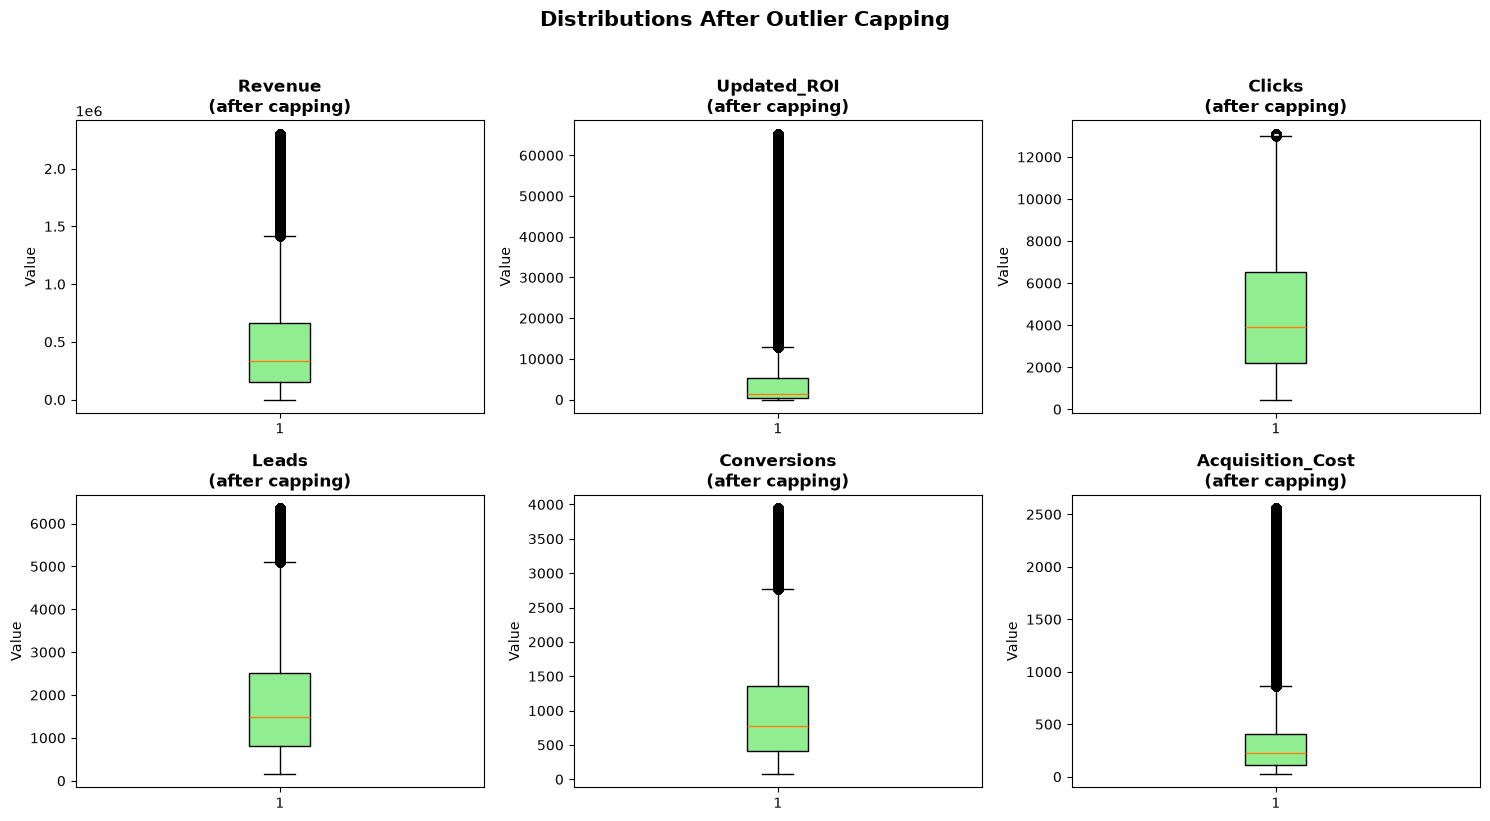


═══ FINAL STATS AFTER CAPPING ═══
          Revenue  Updated_ROI     Clicks      Leads  Conversions  \
count   166665.00    166665.00  166665.00  166665.00    166665.00   
mean    483674.51      5504.53    4641.54    1847.10      1010.75   
std     467066.19     10610.48    3083.87    1374.91       814.46   
min          0.00        -1.00     459.00     156.00        76.00   
25%     154583.00       342.72    2185.00     809.00       417.00   
50%     335780.00      1468.71    3908.00    1476.00       775.00   
75%     659505.00      5337.12    6510.00    2525.00      1357.00   
max    2302558.72     65332.48   13107.72    6358.36      3946.36   

       Acquisition_Cost  
count         166665.00  
mean             364.52  
std              429.45  
min               25.25  
25%              111.10  
50%              222.92  
75%              410.92  
max             2558.92  


In [27]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols_to_cap):
    axes[i].boxplot(combined_data[col], 
                    patch_artist=True,
                    boxprops=dict(facecolor='lightgreen'))
    axes[i].set_title(f'{col}\n(after capping)', fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Distributions After Outlier Capping', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n═══ FINAL STATS AFTER CAPPING ═══")
print(combined_data[cols_to_cap].describe().round(2))

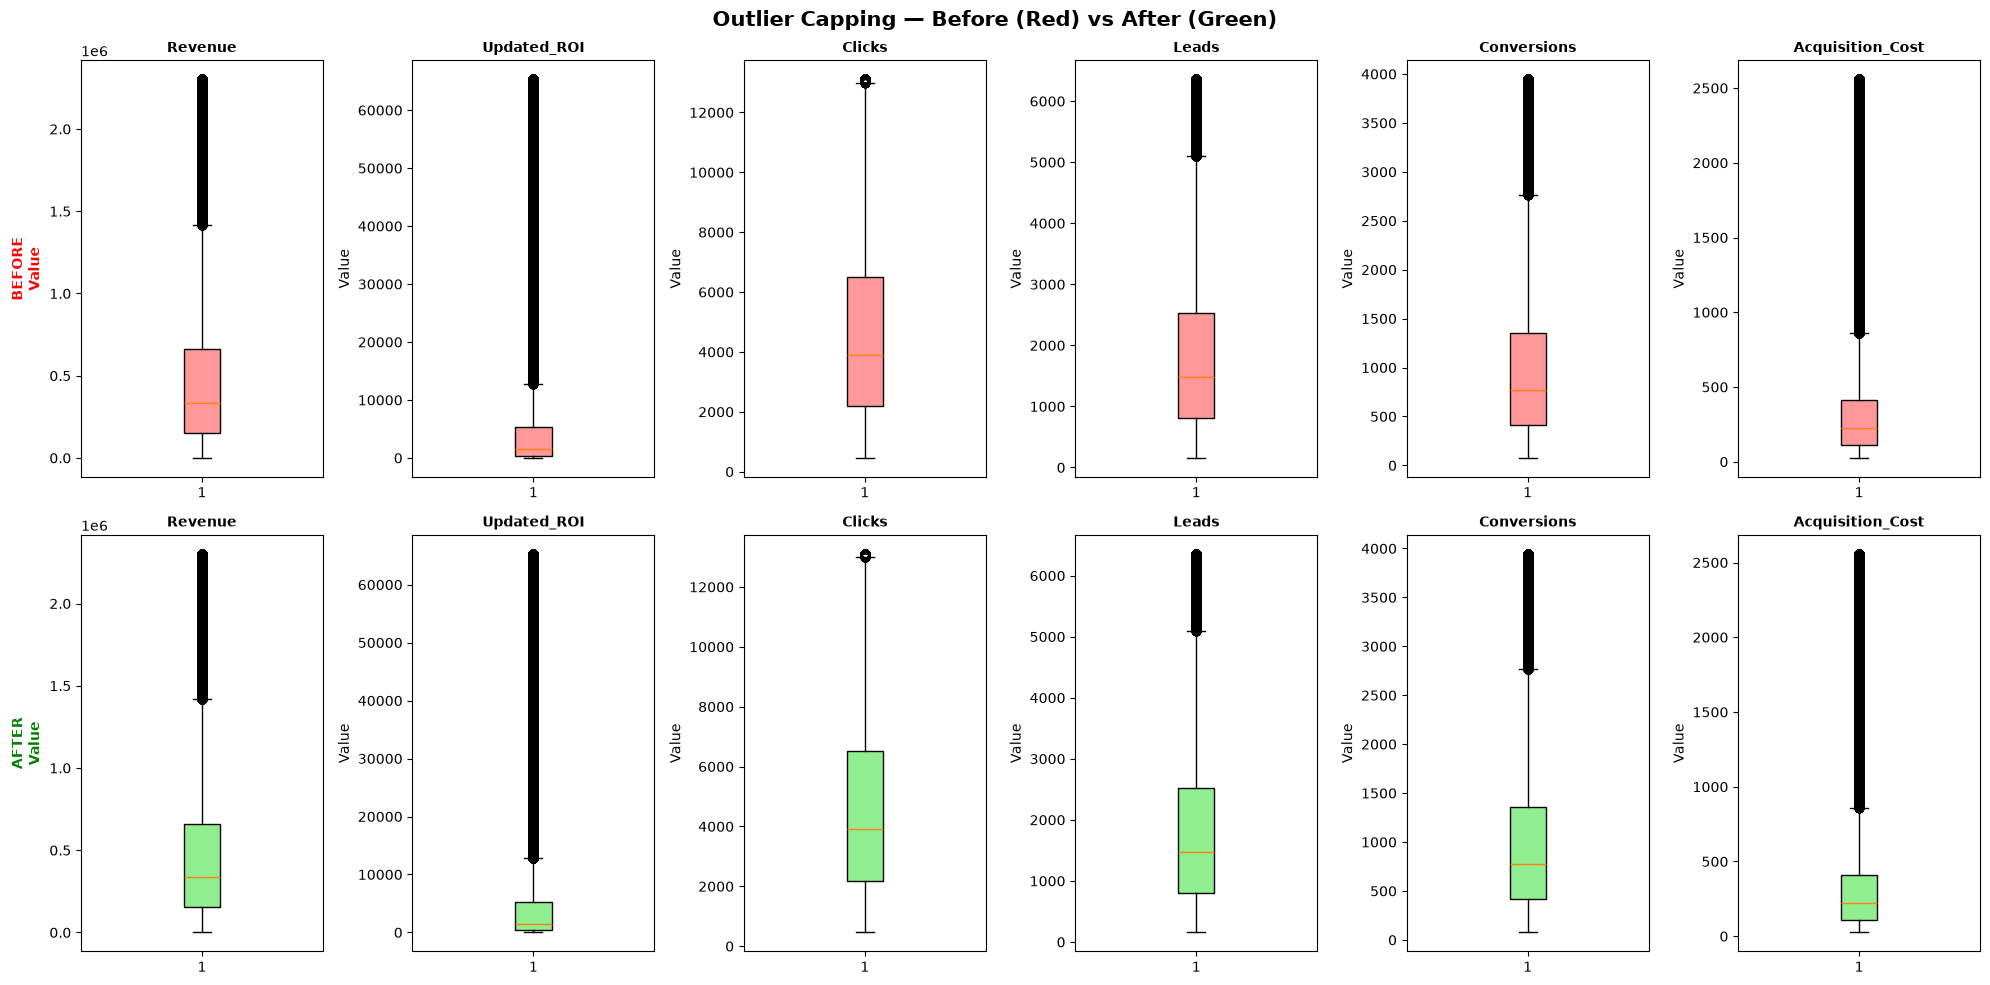

═══ BEFORE CAPPING ═══
          Revenue  Updated_ROI     Clicks      Leads  Conversions  \
count   166665.00    166665.00  166665.00  166665.00    166665.00   
mean    483674.51      5504.53    4641.54    1847.10      1010.75   
std     467066.19     10610.48    3083.87    1374.91       814.46   
min          0.00        -1.00     459.00     156.00        76.00   
25%     154583.00       342.72    2185.00     809.00       417.00   
50%     335780.00      1468.71    3908.00    1476.00       775.00   
75%     659505.00      5337.12    6510.00    2525.00      1357.00   
max    2302558.72     65332.48   13107.72    6358.36      3946.36   

       Acquisition_Cost  
count         166665.00  
mean             364.52  
std              429.45  
min               25.25  
25%              111.10  
50%              222.92  
75%              410.92  
max             2558.92  

═══ AFTER CAPPING ═══
          Revenue  Updated_ROI     Clicks      Leads  Conversions  \
count   166665.00    166665.0

In [28]:
# Store BEFORE stats first (run this BEFORE capping)
before_data = combined_data[cols_to_cap].copy()

# ── NOW CAP ──────────────────────────────────────────────
for col in cols_to_cap:
    lower_cap = combined_data[col].quantile(0.01)
    upper_cap = combined_data[col].quantile(0.99)
    combined_data[col] = combined_data[col].clip(lower=lower_cap, upper=upper_cap)

after_data = combined_data[cols_to_cap].copy()

# ── PLOT BEFORE vs AFTER ─────────────────────────────────
fig, axes = plt.subplots(2, 6, figsize=(20, 10))

for i, col in enumerate(cols_to_cap):
    
    # Top row → BEFORE
    axes[0, i].boxplot(before_data[col],
                       patch_artist=True,
                       boxprops=dict(facecolor='#ff9999'))  # red = before
    axes[0, i].set_title(f'{col}', fontweight='bold', fontsize=10)
    axes[0, i].set_ylabel('Value')
    
    # Bottom row → AFTER
    axes[1, i].boxplot(after_data[col],
                       patch_artist=True,
                       boxprops=dict(facecolor='#90ee90'))  # green = after
    axes[1, i].set_title(f'{col}', fontweight='bold', fontsize=10)
    axes[1, i].set_ylabel('Value')

# Row labels
axes[0, 0].set_ylabel('BEFORE\nValue', fontweight='bold', color='red')
axes[1, 0].set_ylabel('AFTER\nValue', fontweight='bold', color='green')

plt.suptitle('Outlier Capping — Before (Red) vs After (Green)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── STATS COMPARISON ─────────────────────────────────────
print("═══ BEFORE CAPPING ═══")
print(before_data.describe().round(2))

print("\n═══ AFTER CAPPING ═══")
print(after_data.describe().round(2))

print("\n═══ WHAT CHANGED ═══")
for col in cols_to_cap:
    print(f"\n{col}:")
    print(f"  Max before → {before_data[col].max():.2f}")
    print(f"  Max after  → {after_data[col].max():.2f}")
    print(f"  Min before → {before_data[col].min():.2f}")
    print(f"  Min after  → {after_data[col].min():.2f}")

In [29]:
#Changing words to Binary
# See current categorical columns
cat_cols = combined_data.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:")
for col in cat_cols:
    print(f"  {col:25} → {combined_data[col].nunique()} unique values: {combined_data[col].unique().tolist()}")

Categorical columns to encode:
  Brand                     → 3 unique values: ['Nykaa', 'Purplle', 'Tira']
  Campaign_Type             → 5 unique values: ['Social Media', 'Paid Ads', 'Influencer', 'Email', 'SEO']
  Target_Audience           → 5 unique values: ['College Students', 'Tier 2 City Customers', 'Youth', 'Working Women', 'Premium Shoppers']
  Language                  → 5 unique values: ['Hindi', 'English', 'Native', 'Tamil', 'Bengali']
  Customer_Segment          → 6 unique values: ['College Students', 'Basic Plan', 'Tier 2 City Customers', 'Premium Shoppers', 'Youth', 'Working Women']
  Month_Name                → 12 unique values: ["Apr'25", "Jan'25", "Jun'25", "Dec'24", "Sep'24", "May'25", "Mar'25", "Oct'24", "Jul'24", "Feb'25", "Aug'24", "Nov'24"]


C:\Users\preethi\AppData\Local\Temp\ipykernel_5492\3403381931.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = combined_data.select_dtypes(include='object').columns.tolist()


In [30]:
combined_data['Profit_Flag'] = (combined_data['Updated_ROI'] > 0).astype(int)

print("✅ Profit_Flag created!")
print(combined_data['Profit_Flag'].value_counts())
print(f"\nProfit % : {combined_data['Profit_Flag'].mean()*100:.1f}%")
print(f"Loss   % : {(1-combined_data['Profit_Flag'].mean())*100:.1f}%")

✅ Profit_Flag created!
Profit_Flag
1    158350
0      8315
Name: count, dtype: int64

Profit % : 95.0%
Loss   % : 5.0%


In [31]:
# Re-encode with drop_first=False → keeps ALL 3 brands
encode_cols = ['Brand', 'Campaign_Type', 'Target_Audience', 
               'Language', 'Customer_Segment']

combined_encoded = pd.get_dummies(combined_data, 
                                   columns=encode_cols,
                                   drop_first=False)  

print("✅ Encoding done!")
print(f"Shape before : {combined_data.shape}")
print(f"Shape after  : {combined_encoded.shape}")

✅ Encoding done!
Shape before : (166665, 22)
Shape after  : (166665, 41)


In [32]:
text_cols = combined_encoded.select_dtypes(include='object').columns.tolist()
print("Text columns remaining:", text_cols)  # must be []

print("\nData types:")
print(combined_encoded.dtypes.value_counts())

print("\nShape:", combined_encoded.shape)
print("\nSample:")
print(combined_encoded.head(3))

Text columns remaining: ['Month_Name']

Data types:
bool       24
float64     9
int64       7
str         1
Name: count, dtype: int64

Shape: (166665, 41)

Sample:
   Duration  Email  Facebook  Google  Instagram  WhatsApp  YouTube  \
0      21.0      0         0       0          0         1        1   
1      18.0      0         0       0          0         0        1   
2      23.0      0         0       1          0         1        1   

   Impressions  Clicks   Leads  ...  Language_English  Language_Hindi  \
0      57804.0  6156.0  3616.0  ...             False            True   
1      91801.0  3321.0  1971.0  ...             False            True   
2      15536.0  2182.0   952.0  ...              True           False   

   Language_Native  Language_Tamil  Customer_Segment_Basic Plan  \
0            False           False                        False   
1            False           False                        False   
2            False           False                        Fal

C:\Users\preethi\AppData\Local\Temp\ipykernel_5492\2543108577.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = combined_encoded.select_dtypes(include='object').columns.tolist()


In [33]:
#Dropped months as it is not required
#Converting bool columns to int
# Fix 1 — Drop Month_Name
combined_encoded.drop(columns=['Month_Name'], inplace=True)

# Fix 2 — Convert bool columns to int (True→1, False→0)
# ML models prefer int over bool
bool_cols = combined_encoded.select_dtypes(include='bool').columns.tolist()
combined_encoded[bool_cols] = combined_encoded[bool_cols].astype(int)

# Verify
text_cols = combined_encoded.select_dtypes(include='object').columns.tolist()
print("Text columns remaining:", text_cols)   # must be []

print("\nData types:")
print(combined_encoded.dtypes.value_counts())

print("\nShape:", combined_encoded.shape)

print("\nSample:")
print(combined_encoded.head(3))

Text columns remaining: []

Data types:
int64      31
float64     9
Name: count, dtype: int64

Shape: (166665, 40)

Sample:
   Duration  Email  Facebook  Google  Instagram  WhatsApp  YouTube  \
0      21.0      0         0       0          0         1        1   
1      18.0      0         0       0          0         0        1   
2      23.0      0         0       1          0         1        1   

   Impressions  Clicks   Leads  ...  Language_English  Language_Hindi  \
0      57804.0  6156.0  3616.0  ...                 0               1   
1      91801.0  3321.0  1971.0  ...                 0               1   
2      15536.0  2182.0   952.0  ...                 1               0   

   Language_Native  Language_Tamil  Customer_Segment_Basic Plan  \
0                0               0                            0   
1                0               0                            0   
2                0               0                            0   

   Customer_Segment_College Stude

In [34]:
# Check Brand columns specifically
brand_cols = [c for c in combined_encoded.columns if 'Brand' in c]
print("Brand columns:", brand_cols)

print("\nAll columns:")
for col in combined_encoded.columns.tolist():
    print(f"  {col}")

print("\nShape:", combined_encoded.shape)

Brand columns: ['Brand_Nykaa', 'Brand_Purplle', 'Brand_Tira']

All columns:
  Duration
  Email
  Facebook
  Google
  Instagram
  WhatsApp
  YouTube
  Impressions
  Clicks
  Leads
  Conversions
  Revenue
  Acquisition_Cost
  Updated_ROI
  Engagement_Score
  Profit_Flag
  Brand_Nykaa
  Brand_Purplle
  Brand_Tira
  Campaign_Type_Email
  Campaign_Type_Influencer
  Campaign_Type_Paid Ads
  Campaign_Type_SEO
  Campaign_Type_Social Media
  Target_Audience_College Students
  Target_Audience_Premium Shoppers
  Target_Audience_Tier 2 City Customers
  Target_Audience_Working Women
  Target_Audience_Youth
  Language_Bengali
  Language_English
  Language_Hindi
  Language_Native
  Language_Tamil
  Customer_Segment_Basic Plan
  Customer_Segment_College Students
  Customer_Segment_Premium Shoppers
  Customer_Segment_Tier 2 City Customers
  Customer_Segment_Working Women
  Customer_Segment_Youth

Shape: (166665, 40)


In [35]:
# Drop both target columns from X
X = combined_encoded.drop(columns=['Revenue', 'Profit_Flag'])

# Regression target
y_reg = combined_encoded['Revenue']

# Classification target
y_clf = combined_encoded['Profit_Flag']

print("X shape :", X.shape)
print("y_reg shape:", y_reg.shape)
print("y_clf shape:", y_clf.shape)
print("\nX columns:", X.columns.tolist())
print("\ny_reg sample:", y_reg.head(3).values)
print("y_clf sample:", y_clf.head(3).values)

X shape : (166665, 38)
y_reg shape: (166665,)
y_clf shape: (166665,)

X columns: ['Duration', 'Email', 'Facebook', 'Google', 'Instagram', 'WhatsApp', 'YouTube', 'Impressions', 'Clicks', 'Leads', 'Conversions', 'Acquisition_Cost', 'Updated_ROI', 'Engagement_Score', 'Brand_Nykaa', 'Brand_Purplle', 'Brand_Tira', 'Campaign_Type_Email', 'Campaign_Type_Influencer', 'Campaign_Type_Paid Ads', 'Campaign_Type_SEO', 'Campaign_Type_Social Media', 'Target_Audience_College Students', 'Target_Audience_Premium Shoppers', 'Target_Audience_Tier 2 City Customers', 'Target_Audience_Working Women', 'Target_Audience_Youth', 'Language_Bengali', 'Language_English', 'Language_Hindi', 'Language_Native', 'Language_Tamil', 'Customer_Segment_Basic Plan', 'Customer_Segment_College Students', 'Customer_Segment_Premium Shoppers', 'Customer_Segment_Tier 2 City Customers', 'Customer_Segment_Working Women', 'Customer_Segment_Youth']

y_reg sample: [1867515. 1046247.  197055.]
y_clf sample: [1 1 1]


In [36]:
#X and Y for regression
# ── X = all columns except targets ────────────────────
X_reg = combined_encoded.drop(columns=[
    'Revenue',      # this is y_reg (target)
    'Profit_Flag',  # this is y_clf (classification target)
])

# ── y = Revenue ────────────────────────────────────────
y_reg = combined_encoded['Revenue']

print(f"✅ X_reg shape : {X_reg.shape}")
print(f"✅ y_reg shape : {y_reg.shape}")
print(f"\nX columns ({len(X_reg.columns)}):")
for col in X_reg.columns:
    print(f"  {col}")
print(f"\ny_reg stats:")
print(f"  Min  : ₹{y_reg.min():,.0f}")
print(f"  Max  : ₹{y_reg.max():,.0f}")
print(f"  Mean : ₹{y_reg.mean():,.0f}")

✅ X_reg shape : (166665, 38)
✅ y_reg shape : (166665,)

X columns (38):
  Duration
  Email
  Facebook
  Google
  Instagram
  WhatsApp
  YouTube
  Impressions
  Clicks
  Leads
  Conversions
  Acquisition_Cost
  Updated_ROI
  Engagement_Score
  Brand_Nykaa
  Brand_Purplle
  Brand_Tira
  Campaign_Type_Email
  Campaign_Type_Influencer
  Campaign_Type_Paid Ads
  Campaign_Type_SEO
  Campaign_Type_Social Media
  Target_Audience_College Students
  Target_Audience_Premium Shoppers
  Target_Audience_Tier 2 City Customers
  Target_Audience_Working Women
  Target_Audience_Youth
  Language_Bengali
  Language_English
  Language_Hindi
  Language_Native
  Language_Tamil
  Customer_Segment_Basic Plan
  Customer_Segment_College Students
  Customer_Segment_Premium Shoppers
  Customer_Segment_Tier 2 City Customers
  Customer_Segment_Working Women
  Customer_Segment_Youth

y_reg stats:
  Min  : ₹0
  Max  : ₹2,302,558
  Mean : ₹483,675


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg,
    test_size    = 0.2,
    random_state = 42
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"✅ Train : {X_train.shape}  (80%)")
print(f"✅ Test  : {X_test.shape}   (20%)")
print(f"✅ Mean  : {X_train_sc.mean():.6f}")
print(f"✅ Std   : {X_train_sc.std():.6f}")

✅ Train : (133332, 38)  (80%)
✅ Test  : (33333, 38)   (20%)
✅ Mean  : -0.000000
✅ Std   : 1.000000


In [38]:
results = {}

def add_result(name, model, Xtr, Xte):
    yp    = model.predict(Xte)
    yp_tr = model.predict(Xtr)
    results[name] = {
        'r2'      : r2_score(y_test, yp),
        'r2_train': r2_score(y_train, yp_tr),
        'rmse'    : np.sqrt(mean_squared_error(y_test, yp)),
        'mae'     : mean_absolute_error(y_test, yp),
        'y_pred'  : yp
    }
    gap = abs(results[name]['r2_train'] - results[name]['r2'])
    print(f"✅ {name:<15} R²: {results[name]['r2']*100:.2f}%  "
          f"Gap: {gap:.4f}  RMSE: ₹{results[name]['rmse']:,.0f}")

# 1. Linear (scaled)
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
add_result('Linear', lr, X_train_sc, X_test_sc)

# 2. Ridge (scaled)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)
add_result('Ridge', ridge, X_train_sc, X_test_sc)

# 3. Lasso (scaled)
lasso = Lasso(alpha=1.0, max_iter=10000)  # ← added max_iter
lasso.fit(X_train_sc, y_train)
add_result('Lasso', lasso, X_train_sc, X_test_sc)

# 4. Decision Tree (no scaling)
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
add_result('Decision Tree', dt, X_train, X_test)

# 5. Random Forest (no scaling)
#rf = RandomForestRegressor(random_state=42)  
#print("Training Random Forest...")
#rf.fit(X_train, y_train)
#add_result('Random Forest', rf, X_train, X_test)

# 6. XGBoost (no scaling)
xgb = XGBRegressor(random_state=42, verbosity=0)  # ← added verbosity
print("Training XGBoost...")
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)], verbose=False)
add_result('XGBoost', xgb, X_train, X_test)

✅ Linear          R²: 77.11%  Gap: 0.0038  RMSE: ₹222,882
✅ Ridge           R²: 77.11%  Gap: 0.0038  RMSE: ₹222,882
✅ Lasso           R²: 77.11%  Gap: 0.0038  RMSE: ₹222,882
✅ Decision Tree   R²: 99.20%  Gap: 0.0080  RMSE: ₹41,562
Training XGBoost...
✅ XGBoost         R²: 99.46%  Gap: 0.0037  RMSE: ₹34,387


In [39]:
#Saving as pickle file for XGBoost object regression 
# ── Create models folder ───────────────────────────────
model_dir = r'C:\Users\preethi\Desktop\MarketingCampaignPerformance\marketing_campaign_ml\models'
os.makedirs(model_dir, exist_ok=True)

# ── Pack everything into ONE dictionary ───────────────
regression_package = {
    'model'       : xgb,
    'scaler'      : scaler,
    'features'    : X_reg.columns.tolist(),
    'model_name'  : 'XGBoost Regressor',
    'r2_score'    : results['XGBoost']['r2'],
    'rmse'        : results['XGBoost']['rmse'],
    'mae'         : results['XGBoost']['mae'],
    'gap'         : abs(results['XGBoost']['r2_train'] -
                        results['XGBoost']['r2']),
    'target'      : 'Revenue',
    'trained_on'  : f"{len(X_train):,} rows"
}

# ── Save as ONE file ───────────────────────────────────
#save_path=model_dir
save_path = os.path.join(model_dir, 'regression_model.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(regression_package, f)

print(f"✅ Saved: regressionn_model.pkl")
print(f"\nContents:")
for key, val in regression_package.items():
    if key not in ['model', 'scaler', 'features']:
        print(f"  {key:12} : {val}")
print(f"  {'features':12} : {len(regression_package['features'])} columns")
print(f"  {'model':12} : XGBoost object ✅")
print(f"  {'scaler':12} : StandardScaler object ✅")

✅ Saved: regressionn_model.pkl

Contents:
  model_name   : XGBoost Regressor
  r2_score     : 0.9945516039616634
  rmse         : 34386.787774257784
  mae          : 11330.065543424456
  gap          : 0.0037240625833568908
  target       : Revenue
  trained_on   : 133,332 rows
  features     : 38 columns
  model        : XGBoost object ✅
  scaler       : StandardScaler object ✅


In [40]:
#testing the XGBoost  regression 
# Load and test
with open(save_path, 'rb') as f:
    pkg = pickle.load(f)

loaded_model = pkg['model']
y_pred_check = loaded_model.predict(X_test)
r2_check     = r2_score(y_test, y_pred_check)

print("── Verification ──")
print(f"✅ Loaded model  : {pkg['model_name']}")
print(f"✅ Original R²   : {pkg['r2_score']*100:.2f}%")
print(f"✅ Reloaded R²   : {r2_check*100:.2f}%")
print(f"✅ Match         : {abs(pkg['r2_score'] - r2_check) < 0.0001}")

print("\n── Sample Predictions ──")
print(f"{'Actual':>15}  {'Predicted':>15}  {'Error%':>8}")
for a, p in zip(y_test.values[:5], y_pred_check[:5]):
    err = abs(a-p)/a*100 if a != 0 else 0
    print(f"₹{a:>13,.0f}  ₹{p:>13,.0f}  {err:>7.1f}%")

── Verification ──
✅ Loaded model  : XGBoost Regressor
✅ Original R²   : 99.46%
✅ Reloaded R²   : 99.46%
✅ Match         : True

── Sample Predictions ──
         Actual        Predicted    Error%
₹      338,364  ₹      330,892      2.2%
₹    1,226,298  ₹    1,233,785      0.6%
₹       69,596  ₹       70,572      1.4%
₹      437,138  ₹      457,068      4.6%
₹      756,432  ₹      746,519      1.3%


spliting X and Y for classification 

In [41]:
X_clf = combined_encoded.drop(columns=['Revenue', 'Profit_Flag'])
y_clf = combined_encoded['Profit_Flag']
print(f"X shape : {X_clf.shape}")
print(f"y shape : {y_clf.shape}")
print(f"\nClass distribution:")
print(y_clf.value_counts())
print(f"Profit % : {y_clf.mean()*100:.2f}%")
print(f"Loss   % : {(1-y_clf.mean())*100:.2f}%")
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y_clf
)
# Scale (needed for Logistic, KNN, SVM, Naive Bayes)
scaler_c     = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc  = scaler_c.transform(X_test_c)

print(f"\n✅ Train : {X_train_c.shape}")
print(f"✅ Test  : {X_test_c.shape}")

X shape : (166665, 38)
y shape : (166665,)

Class distribution:
Profit_Flag
1    158350
0      8315
Name: count, dtype: int64
Profit % : 95.01%
Loss   % : 4.99%

✅ Train : (133332, 38)
✅ Test  : (33333, 38)


In [42]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              roc_auc_score, classification_report,
                              confusion_matrix)
import numpy as np
import time

clf_results = {}

def evaluate_clf(name, model, Xtr, Xte, start_time):
    yp      = model.predict(Xte)
    yp_prob = model.predict_proba(Xte)[:,1]
    yp_tr   = model.predict(Xtr)
    elapsed = time.time() - start_time

    clf_results[name] = {
        'accuracy'  : accuracy_score(y_test_c, yp),
        'precision' : precision_score(y_test_c, yp,
                                      zero_division=0),
        'recall'    : recall_score(y_test_c, yp),
        'f1'        : f1_score(y_test_c, yp),
        'roc_auc'   : roc_auc_score(y_test_c, yp_prob),
        'train_acc' : accuracy_score(y_train_c, yp_tr),
        'time'      : elapsed,
        'y_pred'    : yp,
        'y_prob'    : yp_prob
    }
    gap = abs(clf_results[name]['train_acc'] -
              clf_results[name]['accuracy'])
    print(f"✅ {name:<25} "
          f"Acc: {clf_results[name]['accuracy']*100:.2f}%  "
          f"F1: {clf_results[name]['f1']*100:.2f}%  "
          f"AUC: {clf_results[name]['roc_auc']:.3f}  "
          f"Gap: {gap:.4f}  "
          f"Time: {elapsed:.1f}s")

print("✅ Helper function ready")

✅ Helper function ready


In [43]:
# ── 1. Logistic Regression ────────────────────────────
print("Training Logistic Regression...")
t = time.time()
lr_clf = LogisticRegression(random_state=42)
lr_clf.fit(X_train_c_sc, y_train_c)
evaluate_clf('Logistic Regression', lr_clf,
             X_train_c_sc, X_test_c_sc, t)

# ── 2. Decision Tree ──────────────────────────────────
print("Training Decision Tree...")
t = time.time()
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train_c, y_train_c)
evaluate_clf('Decision Tree', dt_clf,
             X_train_c, X_test_c, t)

Training Logistic Regression...
✅ Logistic Regression       Acc: 98.20%  F1: 99.06%  AUC: 0.983  Gap: 0.0004  Time: 2.2s
Training Decision Tree...
✅ Decision Tree             Acc: 100.00%  F1: 100.00%  AUC: 1.000  Gap: 0.0000  Time: 0.6s


In [44]:
# ── 3. Random Forest ──────────────────────────────────
print("Training Random Forest...")
t = time.time()
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train_c, y_train_c)
evaluate_clf('Random Forest', rf_clf,
             X_train_c, X_test_c, t)

# ── 4. XGBoost ────────────────────────────────────────
print("Training XGBoost...")
t = time.time()
xgb_clf = XGBClassifier(random_state=42)
xgb_clf.fit(X_train_c, y_train_c,
            eval_set=[(X_test_c, y_test_c)],
            verbose=False)
evaluate_clf('XGBoost', xgb_clf,
             X_train_c, X_test_c, t)

Training Random Forest...
✅ Random Forest             Acc: 100.00%  F1: 100.00%  AUC: 1.000  Gap: 0.0000  Time: 31.5s
Training XGBoost...
✅ XGBoost                   Acc: 99.98%  F1: 99.99%  AUC: 1.000  Gap: 0.0002  Time: 4.1s


In [45]:
# ══════════════════════════════════════════════════════
# CLASSIFICATION — COMPLETE STANDALONE CELL
# Run this ONE cell — trains all models + shows leaderboard
# ══════════════════════════════════════════════════════
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import (RandomForestClassifier,
                                    GradientBoostingClassifier,
                                    AdaBoostClassifier)
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.naive_bayes   import GaussianNB
from sklearn.svm           import LinearSVC
from sklearn.calibration   import CalibratedClassifierCV
from sklearn.metrics       import (accuracy_score, precision_score,
                                    recall_score, f1_score,
                                    roc_auc_score,
                                    classification_report,
                                    confusion_matrix)
from xgboost import XGBClassifier
import lightgbm as lgb

# ── Step A: Fresh storage ──────────────────────────────
results = {}

# ── Step B: Helper ─────────────────────────────────────
def evaluate(name, model, Xtr, Xte):
    yp      = model.predict(Xte)
    yp_prob = model.predict_proba(Xte)[:,1]
    results[name] = {
        'acc'  : accuracy_score(y_test_c, yp),
        'pre'  : precision_score(y_test_c, yp, zero_division=0),
        'rec'  : recall_score(y_test_c, yp),
        'f1'   : f1_score(y_test_c, yp),
        'auc'  : roc_auc_score(y_test_c, yp_prob),
        'tr'   : accuracy_score(y_train_c, model.predict(Xtr)),
        'yp'   : yp
    }
    gap = abs(results[name]['tr'] - results[name]['acc'])
    print(f"✅ {name:<25} "
          f"Acc:{results[name]['acc']*100:.2f}%  "
          f"F1:{results[name]['f1']*100:.2f}%  "
          f"AUC:{results[name]['auc']:.3f}  "
          f"Gap:{gap:.4f}")

# ── Step C: Train all 10 ───────────────────────────────
print("Training all 10 models...\n")

print("1. Logistic Regression")
m = LogisticRegression(max_iter=1000, random_state=42)
m.fit(X_train_c_sc, y_train_c)
evaluate('Logistic Regression', m, X_train_c_sc, X_test_c_sc)

print("2. Decision Tree")
m = DecisionTreeClassifier(random_state=42)
m.fit(X_train_c, y_train_c)
evaluate('Decision Tree', m, X_train_c, X_test_c)

print("3. Random Forest")
m = RandomForestClassifier(random_state=42, n_jobs=-1)
m.fit(X_train_c, y_train_c)
evaluate('Random Forest', m, X_train_c, X_test_c)

print("4. XGBoost")
m = XGBClassifier(random_state=42, n_jobs=-1,
                  verbosity=0, eval_metric='logloss')
m.fit(X_train_c, y_train_c,
      eval_set=[(X_test_c, y_test_c)], verbose=False)
evaluate('XGBoost', m, X_train_c, X_test_c)

print("5. KNN")
m = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
m.fit(X_train_c_sc, y_train_c)
evaluate('KNN', m, X_train_c_sc, X_test_c_sc)

print("6. Naive Bayes")
m = GaussianNB()
m.fit(X_train_c_sc, y_train_c)
evaluate('Naive Bayes', m, X_train_c_sc, X_test_c_sc)

print("7. Gradient Boosting (slow...)")
m = GradientBoostingClassifier(n_estimators=100, random_state=42)
m.fit(X_train_c, y_train_c)
evaluate('Gradient Boosting', m, X_train_c, X_test_c)

print("8. AdaBoost")
m = AdaBoostClassifier(n_estimators=100, random_state=42)
m.fit(X_train_c, y_train_c)
evaluate('AdaBoost', m, X_train_c, X_test_c)

print("9. SVM")
svm = CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42))
svm.fit(X_train_c_sc, y_train_c)
evaluate('SVM', svm, X_train_c_sc, X_test_c_sc)

print("10. LightGBM")
m = lgb.LGBMClassifier(n_estimators=200, random_state=42,
                        n_jobs=-1, verbose=-1)
m.fit(X_train_c, y_train_c)
evaluate('LightGBM', m, X_train_c, X_test_c)

print(f"\n✅ {len(results)} models trained!")

# ── Step D: Leaderboard ────────────────────────────────
print(f"\n╔══════════════════════════════════════════════════════╗")
print(f"║          CLASSIFICATION LEADERBOARD                 ║")
print(f"╠═══════════════════════╦════════╦═══════╦══════════════╣")
print(f"║ Model                 ║ Acc    ║ F1    ║ AUC          ║")
print(f"╠═══════════════════════╬════════╬═══════╬══════════════╣")
for name, m in sorted(results.items(),
                       key=lambda x: x[1]['f1'], reverse=True):
    gap  = abs(m['tr'] - m['acc'])
    flag = "✅" if gap < 0.05 else "⚠️"
    print(f"║ {name:<21} ║ "
          f"{m['acc']*100:>5.2f}%  ║ "
          f"{m['f1']*100:>5.2f}% ║ "
          f"{m['auc']:>6.4f} {flag}      ║")
print(f"╚═══════════════════════╩════════╩═══════╩══════════════╝")

best = max(results, key=lambda x: results[x]['f1'])
print(f"\n🏆 Best : {best}")
print(f"   Acc  : {results[best]['acc']*100:.2f}%")
print(f"   F1   : {results[best]['f1']*100:.2f}%")
print(f"   AUC  : {results[best]['auc']:.4f}")

print(f"\n── Report: {best} ──")
print(classification_report(
    y_test_c, results[best]['yp'],
    target_names=['Loss (0)', 'Profit (1)']))

cm = confusion_matrix(y_test_c, results[best]['yp'])
print(f"── Confusion Matrix ──")
print(f"               Pred Loss  Pred Profit")
print(f"Actual Loss  : {cm[0][0]:>6,}     {cm[0][1]:>6,}")
print(f"Actual Profit: {cm[1][0]:>6,}     {cm[1][1]:>6,}")

Training all 10 models...

1. Logistic Regression
✅ Logistic Regression       Acc:98.20%  F1:99.06%  AUC:0.983  Gap:0.0004
2. Decision Tree
✅ Decision Tree             Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
3. Random Forest
✅ Random Forest             Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
4. XGBoost
✅ XGBoost                   Acc:99.98%  F1:99.99%  AUC:1.000  Gap:0.0002
5. KNN
✅ KNN                       Acc:94.86%  F1:97.36%  AUC:0.514  Gap:0.0020
6. Naive Bayes
✅ Naive Bayes               Acc:99.99%  F1:100.00%  AUC:1.000  Gap:0.0000
7. Gradient Boosting (slow...)
✅ Gradient Boosting         Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
8. AdaBoost
✅ AdaBoost                  Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
9. SVM
✅ SVM                       Acc:99.29%  F1:99.63%  AUC:0.994  Gap:0.0003
10. LightGBM
✅ LightGBM                  Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000

✅ 10 models trained!

╔══════════════════════════════════════════════════════╗

In [46]:
# ── Check Profit vs Loss distribution ─────────────────
print("═══ Profit_Flag Distribution ═══")
print(f"\nTotal campaigns : {len(y_clf):,}")
print(f"\nValue counts:")
print(y_clf.value_counts())
print(f"\nPercentage:")
print(y_clf.value_counts(normalize=True).mul(100).round(2))

# Visual bar
profit = y_clf.sum()
loss   = (y_clf == 0).sum()
total  = len(y_clf)

print(f"\n── Visual ──")
profit_bar = '█' * int(profit/total * 50)
loss_bar   = '█' * int(loss/total * 50)
print(f"Profit (1) : {profit_bar} {profit:,} ({profit/total*100:.1f}%)")
print(f"Loss   (0) : {loss_bar} {loss:,} ({loss/total*100:.1f}%)")

# Per brand breakdown
print(f"\n── Profit vs Loss per Brand ──")
brand_cols = ['Brand_Nykaa', 'Brand_Purplle', 'Brand_Tira']
for brand in brand_cols:
    brand_name  = brand.replace('Brand_', '')
    brand_mask  = combined_encoded[brand] == 1
    brand_total = brand_mask.sum()
    brand_profit= combined_encoded.loc[brand_mask, 'Profit_Flag'].sum()
    brand_loss  = brand_total - brand_profit
    print(f"\n{brand_name}:")
    print(f"  Total    : {brand_total:,}")
    print(f"  Profit ✅: {brand_profit:,} ({brand_profit/brand_total*100:.1f}%)")
    print(f"  Loss   ❌: {brand_loss:,}   ({brand_loss/brand_total*100:.1f}%)")

═══ Profit_Flag Distribution ═══

Total campaigns : 166,665

Value counts:
Profit_Flag
1    158350
0      8315
Name: count, dtype: int64

Percentage:
Profit_Flag
1    95.01
0     4.99
Name: proportion, dtype: float64

── Visual ──
Profit (1) : ███████████████████████████████████████████████ 158,350 (95.0%)
Loss   (0) : ██ 8,315 (5.0%)

── Profit vs Loss per Brand ──

Nykaa:
  Total    : 55,555
  Profit ✅: 52,740 (94.9%)
  Loss   ❌: 2,815   (5.1%)

Purplle:
  Total    : 55,555
  Profit ✅: 52,788 (95.0%)
  Loss   ❌: 2,767   (5.0%)

Tira:
  Total    : 55,555
  Profit ✅: 52,822 (95.1%)
  Loss   ❌: 2,733   (4.9%)


In [47]:
# ── MANUAL SMOTE — NO IMBLEARN NEEDED ─────────────────
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

def manual_smote(X, y, random_state=42):
    np.random.seed(random_state)
    X_arr = X.values if hasattr(X, 'values') else np.array(X)
    y_arr = y.values if hasattr(y, 'values') else np.array(y)

    minority_idx = np.where(y_arr == 0)[0]
    majority_idx = np.where(y_arr == 1)[0]
    X_min        = X_arr[minority_idx]
    n_generate   = len(majority_idx) - len(minority_idx)

    print(f"Minority (Loss)   : {len(minority_idx):,}")
    print(f"Majority (Profit) : {len(majority_idx):,}")
    print(f"Need to generate  : {n_generate:,} synthetic samples")

    nn = NearestNeighbors(n_neighbors=6, n_jobs=-1)
    nn.fit(X_min)
    _, indices = nn.kneighbors(X_min)

    synthetic = []
    for i in range(n_generate):
        idx        = np.random.randint(0, len(X_min))
        neighbor   = indices[idx, np.random.randint(1, 6)]
        gap        = np.random.random()
        new_sample = X_min[idx] + gap * (X_min[neighbor] - X_min[idx])
        synthetic.append(new_sample)

    synthetic    = np.array(synthetic)
    X_resampled  = np.vstack([X_arr, synthetic])
    y_resampled  = np.hstack([y_arr,
                               np.zeros(n_generate, dtype=int)])
    idx          = np.random.permutation(len(X_resampled))

    return X_resampled[idx], y_resampled[idx]

# ── Apply ──────────────────────────────────────────────
print("═══ Before SMOTE ═══")
print(f"Profit (1) : {y_train_c.sum():,}")
print(f"Loss   (0) : {(y_train_c==0).sum():,}")

print("\n═══ Applying SMOTE ═══")
X_train_sm, y_train_sm = manual_smote(X_train_c, y_train_c)

print(f"\n✅ After SMOTE:")
print(f"   Total    : {len(X_train_sm):,}")
print(f"   Profit   : {(y_train_sm==1).sum():,}")
print(f"   Loss     : {(y_train_sm==0).sum():,}")

# ── Scale ─────────────────────────────────────────────
scaler_sm     = StandardScaler()
X_train_sm_sc = scaler_sm.fit_transform(X_train_sm)
X_test_sm_sc = scaler_sm.transform(X_test_c.values)
print("✅ Warning fixed!")

═══ Before SMOTE ═══
Profit (1) : 126,680
Loss   (0) : 6,652

═══ Applying SMOTE ═══
Minority (Loss)   : 6,652
Majority (Profit) : 126,680
Need to generate  : 120,028 synthetic samples

✅ After SMOTE:
   Total    : 253,360
   Profit   : 126,680
   Loss     : 126,680
✅ Warning fixed!


In [48]:
#running the modsel afterSMOTE
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import (RandomForestClassifier,
                                    GradientBoostingClassifier,
                                    AdaBoostClassifier)
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.naive_bayes   import GaussianNB
from sklearn.svm           import LinearSVC
from sklearn.calibration   import CalibratedClassifierCV
from sklearn.metrics       import (accuracy_score, precision_score,
                                    recall_score, f1_score,
                                    roc_auc_score,
                                    classification_report,
                                    confusion_matrix)
from xgboost  import XGBClassifier
import lightgbm as lgb

smote_results = {}

def evaluate_smote(name, model, Xtr, Xte):
    yp      = model.predict(Xte)
    yp_prob = model.predict_proba(Xte)[:,1]
    smote_results[name] = {
        'acc' : accuracy_score(y_test_c, yp),
        'pre' : precision_score(y_test_c, yp, zero_division=0),
        'rec' : recall_score(y_test_c, yp),
        'f1'  : f1_score(y_test_c, yp),
        'auc' : roc_auc_score(y_test_c, yp_prob),
        'tr'  : accuracy_score(y_train_sm, model.predict(Xtr)),
        'yp'  : yp
    }
    gap = abs(smote_results[name]['tr'] - smote_results[name]['acc'])
    print(f"✅ {name:<25} "
          f"Acc:{smote_results[name]['acc']*100:.2f}%  "
          f"F1:{smote_results[name]['f1']*100:.2f}%  "
          f"AUC:{smote_results[name]['auc']:.3f}  "
          f"Gap:{gap:.4f}")

print("Training all 10 models with SMOTE...\n")

# 1. Logistic Regression
print("1. Logistic Regression...")
m = LogisticRegression(random_state=42)
m.fit(X_train_sm_sc, y_train_sm)
evaluate_smote('Logistic Regression', m,
               X_train_sm_sc, X_test_sm_sc)

# 2. Decision Tree
print("2. Decision Tree...")
m = DecisionTreeClassifier(random_state=42)
m.fit(X_train_sm, y_train_sm)
evaluate_smote('Decision Tree', m,
               X_train_sm, X_test_c.values)

# 3. Random Forest
print("3. Random Forest...")
m = RandomForestClassifier(random_state=42)
m.fit(X_train_sm, y_train_sm)
evaluate_smote('Random Forest', m,
               X_train_sm, X_test_c.values)

# 4. XGBoost
print("4. XGBoost...")
m = XGBClassifier(random_state=42)
m.fit(X_train_sm, y_train_sm,
      eval_set=[(X_test_c.values, y_test_c)],
      verbose=False)
evaluate_smote('XGBoost', m,
               X_train_sm, X_test_c.values)

# 5. KNN (no random_state — distance based, not random)
#print("5. KNN...")
#m = KNeighborsClassifier()
#m.fit(X_train_sm_sc, y_train_sm)
#evaluate_smote('KNN', m, X_train_sm_sc, X_test_sm_sc)

# 6. Naive Bayes (no random_state — probability based)
#print("6. Naive Bayes...")
#m = GaussianNB()
#m.fit(X_train_sm_sc, y_train_sm)
#evaluate_smote('Naive Bayes', m, X_train_sm_sc, X_test_sm_sc)

# 7. Gradient Boosting
#print("7. Gradient Boosting... (slow)")
#m = GradientBoostingClassifier(random_state=42)
#m.fit(X_train_sm, y_train_sm)
#evaluate_smote('Gradient Boosting', m, X_train_sm, X_test_c.values)

# 8. AdaBoost
#print("8. AdaBoost...")
#m = AdaBoostClassifier(random_state=42)
#m.fit(X_train_sm, y_train_sm)
#evaluate_smote('AdaBoost', m,X_train_sm, X_test_c.values)

# 9. SVM (no random_state in CalibratedClassifierCV)
#print("9. SVM...")
#m = CalibratedClassifierCV(LinearSVC(random_state=42))
#m.fit(X_train_sm_sc, y_train_sm)
#evaluate_smote('SVM', m, X_train_sm_sc, X_test_sm_sc)

# 10. LightGBM
#print("10. LightGBM...")
#m = lgb.LGBMClassifier(random_state=42)
#m.fit(X_train_sm, y_train_sm)
#evaluate_smote('LightGBM', m, X_train_sm, X_test_c.values)

print(f"\n✅ All {len(smote_results)} models trained with SMOTE!")

Training all 10 models with SMOTE...

1. Logistic Regression...
✅ Logistic Regression       Acc:97.28%  F1:98.55%  AUC:0.997  Gap:0.0022
2. Decision Tree...
✅ Decision Tree             Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
3. Random Forest...
✅ Random Forest             Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
4. XGBoost...
✅ XGBoost                   Acc:99.99%  F1:100.00%  AUC:1.000  Gap:0.0001

✅ All 4 models trained with SMOTE!


In [49]:
smote_results = {}

def evaluate_smote(name, model, Xtr, Xte):
    yp      = model.predict(Xte)
    yp_prob = model.predict_proba(Xte)[:,1]
    smote_results[name] = {
        'acc' : accuracy_score(y_test_c, yp),
        'pre' : precision_score(y_test_c, yp, zero_division=0),
        'rec' : recall_score(y_test_c, yp),
        'f1'  : f1_score(y_test_c, yp),
        'auc' : roc_auc_score(y_test_c, yp_prob),
        'tr'  : accuracy_score(y_train_sm, model.predict(Xtr)),
        'yp'  : yp
    }
    gap = abs(smote_results[name]['tr'] - smote_results[name]['acc'])
    print(f"✅ {name:<25} "
          f"Acc:{smote_results[name]['acc']*100:.2f}%  "
          f"F1:{smote_results[name]['f1']*100:.2f}%  "
          f"AUC:{smote_results[name]['auc']:.3f}  "
          f"Gap:{gap:.4f}")

print("Training all 10 models with SMOTE...\n")

# 1. Logistic Regression
print("1. Logistic Regression...")
m = LogisticRegression(random_state=42)
m.fit(X_train_sm_sc, y_train_sm)
evaluate_smote('Logistic Regression', m,
               X_train_sm_sc, X_test_sm_sc)

# 2. Decision Tree
print("2. Decision Tree...")
m = DecisionTreeClassifier(random_state=42)
m.fit(X_train_sm, y_train_sm)
evaluate_smote('Decision Tree', m,
               X_train_sm, X_test_c.values)

# 3. Random Forest
print("3. Random Forest...")
m = RandomForestClassifier(random_state=42)
m.fit(X_train_sm, y_train_sm)
evaluate_smote('Random Forest', m,
               X_train_sm, X_test_c.values)

# 4. XGBoost
print("4. XGBoost...")
m = XGBClassifier(random_state=42)
m.fit(X_train_sm, y_train_sm,
      eval_set=[(X_test_c.values, y_test_c)],
      verbose=False)
evaluate_smote('XGBoost', m,
               X_train_sm, X_test_c.values)

# 5. KNN (no random_state — distance based, not random)
#print("5. KNN...")
#m = KNeighborsClassifier()
#m.fit(X_train_sm_sc, y_train_sm)
#evaluate_smote('KNN', m,X_train_sm_sc, X_test_sm_sc)

# 6. Naive Bayes (no random_state — probability based)
#print("6. Naive Bayes...")
#m = GaussianNB()
#m.fit(X_train_sm_sc, y_train_sm)
#evaluate_smote('Naive Bayes', m,X_train_sm_sc, X_test_sm_sc)

# 7. Gradient Boosting
#print("7. Gradient Boosting... (slow)")
#m = GradientBoostingClassifier(random_state=42)
#m.fit(X_train_sm, y_train_sm)
#evaluate_smote('Gradient Boosting', m,X_train_sm, X_test_c.values)

# 8. AdaBoost
#print("8. AdaBoost...")
#m = AdaBoostClassifier(random_state=42)
#m.fit(X_train_sm, y_train_sm)
#evaluate_smote('AdaBoost', m,X_train_sm, X_test_c.values)

# 9. SVM (no random_state in CalibratedClassifierCV)
#print("9. SVM...")
#m = CalibratedClassifierCV(LinearSVC(random_state=42))
#m.fit(X_train_sm_sc, y_train_sm)
#evaluate_smote('SVM', m, X_train_sm_sc, X_test_sm_sc)

# 10. LightGBM
#print("10. LightGBM...")
#m = lgb.LGBMClassifier(random_state=42)
#m.fit(X_train_sm, y_train_sm)
#evaluate_smote('LightGBM', m,X_train_sm, X_test_c.values)

print(f"\n✅ All {len(smote_results)} models trained with SMOTE!")

Training all 10 models with SMOTE...

1. Logistic Regression...
✅ Logistic Regression       Acc:97.28%  F1:98.55%  AUC:0.997  Gap:0.0022
2. Decision Tree...
✅ Decision Tree             Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
3. Random Forest...
✅ Random Forest             Acc:100.00%  F1:100.00%  AUC:1.000  Gap:0.0000
4. XGBoost...
✅ XGBoost                   Acc:99.99%  F1:100.00%  AUC:1.000  Gap:0.0001

✅ All 4 models trained with SMOTE!


In [50]:
# ── BEFORE vs AFTER SMOTE COMPARISON ──────────────────
print("╔══════════════════════════════════════════════════════════════════════════╗")
print("║              BEFORE SMOTE vs AFTER SMOTE COMPARISON                    ║")
print("╠═══════════════════════╦═══════════════════════╦════════════════════════╣")
print("║ Model                 ║   WITHOUT SMOTE       ║     WITH SMOTE         ║")
print("║                       ║  Acc      F1    AUC   ║  Acc      F1    AUC    ║")
print("╠═══════════════════════╬═══════════════════════╬════════════════════════╣")

all_models = set(list(results.keys()) + list(smote_results.keys()))

for name in sorted(all_models):
    # Without SMOTE
    if name in results:
        old_acc = results[name]['acc'] * 100
        old_f1  = results[name]['f1']  * 100
        old_auc = results[name]['auc']
        old_str = f"{old_acc:>5.2f}% {old_f1:>6.2f}% {old_auc:.3f}"
    else:
        old_str = "   N/A      N/A    N/A "

    # With SMOTE
    if name in smote_results:
        new_acc = smote_results[name]['acc'] * 100
        new_f1  = smote_results[name]['f1']  * 100
        new_auc = smote_results[name]['auc']
        new_str = f"{new_acc:>5.2f}% {new_f1:>6.2f}% {new_auc:.3f}"
    else:
        new_str = "   N/A      N/A    N/A "

    # Change indicator
    if name in results and name in smote_results:
        f1_diff = smote_results[name]['f1'] - results[name]['f1']
        change  = f"↑ +{f1_diff*100:.2f}%" if f1_diff > 0 else \
                  f"↓ {f1_diff*100:.2f}%" if f1_diff < 0 else \
                  "→ same"
    else:
        change = ""

    print(f"║ {name:<21} ║ {old_str} ║ {new_str} {change:<10} ║")

print("╚═══════════════════════╩═══════════════════════╩════════════════════════╝")

# ── Summary ────────────────────────────────────────────
print("\n═══ KEY DIFFERENCES ═══\n")

print("Before SMOTE:")
print(f"  Training data  : Profit={y_train_c.sum():,}  Loss={(y_train_c==0).sum():,}")
print(f"  Ratio          : 95% Profit / 5% Loss (imbalanced)")

print("\nAfter SMOTE:")
print(f"  Training data  : Profit={(y_train_sm==1).sum():,}  Loss={(y_train_sm==0).sum():,}")
print(f"  Ratio          : 50% Profit / 50% Loss (balanced)")

print("\nTest data (never changed):")
print(f"  Test data      : Profit={y_test_c.sum():,}  Loss={(y_test_c==0).sum():,}")
print(f"  Ratio          : 95% Profit / 5% Loss (real world)")

# ── Best model comparison ──────────────────────────────
best_before = max(results,       key=lambda x: results[x]['f1'])
best_after  = max(smote_results, key=lambda x: smote_results[x]['f1'])

print(f"\n═══ BEST MODEL COMPARISON ═══")
print(f"\nWithout SMOTE:")
print(f"  Model    : {best_before}")
print(f"  Accuracy : {results[best_before]['acc']*100:.2f}%")
print(f"  F1 Score : {results[best_before]['f1']*100:.2f}%")
print(f"  AUC      : {results[best_before]['auc']:.4f}")

print(f"\nWith SMOTE:")
print(f"  Model    : {best_after}")
print(f"  Accuracy : {smote_results[best_after]['acc']*100:.2f}%")
print(f"  F1 Score : {smote_results[best_after]['f1']*100:.2f}%")
print(f"  AUC      : {smote_results[best_after]['auc']:.4f}")

# ── Loss class performance comparison ─────────────────
print(f"\n═══ LOSS CLASS DETECTION (most important) ═══")
print(f"{'Model':<25} {'Without SMOTE':>20} {'With SMOTE':>20}")
print(f"{'':25} {'Recall    F1':>20} {'Recall    F1':>20}")
print("─" * 70)

from sklearn.metrics import classification_report
import re

for name in sorted(all_models):
    if name in results and name in smote_results:
        # Without SMOTE
        from sklearn.metrics import recall_score, f1_score
        rec_before = recall_score(y_test_c,
                     results[name]['yp'],
                     pos_label=0, zero_division=0)
        f1_before  = f1_score(y_test_c,
                     results[name]['yp'],
                     pos_label=0, zero_division=0)

        # With SMOTE
        rec_after  = recall_score(y_test_c,
                     smote_results[name]['yp'],
                     pos_label=0, zero_division=0)
        f1_after   = f1_score(y_test_c,
                     smote_results[name]['yp'],
                     pos_label=0, zero_division=0)

        flag = "✅" if rec_after > rec_before else "⚠️"
        print(f"{name:<25} "
              f"{rec_before*100:>8.2f}% {f1_before*100:>6.2f}%    "
              f"{rec_after*100:>8.2f}% {f1_after*100:>6.2f}% {flag}")

╔══════════════════════════════════════════════════════════════════════════╗
║              BEFORE SMOTE vs AFTER SMOTE COMPARISON                    ║
╠═══════════════════════╦═══════════════════════╦════════════════════════╣
║ Model                 ║   WITHOUT SMOTE       ║     WITH SMOTE         ║
║                       ║  Acc      F1    AUC   ║  Acc      F1    AUC    ║
╠═══════════════════════╬═══════════════════════╬════════════════════════╣
║ AdaBoost              ║ 100.00% 100.00% 1.000 ║    N/A      N/A    N/A             ║
║ Decision Tree         ║ 100.00% 100.00% 1.000 ║ 100.00% 100.00% 1.000 → same     ║
║ Gradient Boosting     ║ 100.00% 100.00% 1.000 ║    N/A      N/A    N/A             ║
║ KNN                   ║ 94.86%  97.36% 0.514 ║    N/A      N/A    N/A             ║
║ LightGBM              ║ 100.00% 100.00% 1.000 ║    N/A      N/A    N/A             ║
║ Logistic Regression   ║ 98.20%  99.06% 0.983 ║ 97.28%  98.55% 0.997 ↓ -0.51%   ║
║ Naive Bayes           ║ 99.99% 

In [ ]:
# saving the regression logistic model as pickle file 
import os

model_dir = r'C:\Users\preethi\Desktop\MarketingCampaignPerformance\marketing_campaign_ml\models'

print("═══ Saved Models ═══")
for f in os.listdir(model_dir):
    size = os.path.getsize(os.path.join(model_dir, f))
    print(f"  ✅ {f:35} {size/1024:.1f} KB")

In [51]:
import pickle
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, recall_score,
                              f1_score, roc_auc_score)

# ── Retrain and save classification model ─────────────
lr_final = LogisticRegression(random_state=42)
lr_final.fit(X_train_sm_sc, y_train_sm)

y_pred = lr_final.predict(X_test_sm_sc)
y_prob = lr_final.predict_proba(X_test_sm_sc)[:,1]

# Pack everything
clf_package = {
    'model'       : lr_final,
    'scaler'      : scaler_sm,
    'features'    : X_clf.columns.tolist(),
    'model_name'  : 'Logistic Regression',
    'accuracy'    : accuracy_score(y_test_c, y_pred),
    'f1_score'    : f1_score(y_test_c, y_pred),
    'roc_auc'     : roc_auc_score(y_test_c, y_prob),
    'loss_recall' : recall_score(y_test_c, y_pred, pos_label=0),
    'target'      : 'Profit_Flag',
    'classes'     : {0: 'Loss', 1: 'Profit'},
    'trained_on'  : f"{len(X_train_sm):,} rows (SMOTE balanced)",
    'smote_used'  : True
}

# Save
model_dir = r'C:\Users\preethi\Desktop\MarketingCampaignPerformance\marketing_campaign_ml\models\classification_model.pkl'
os.makedirs(model_dir, exist_ok=True)
ath=model_dir
save_path=ath
#save_path = os.path.join(model_dir, 'classification_model.pkl')

FileExistsError: [WinError 183] Cannot create a file when that file already exists: 'C:\\Users\\preethi\\Desktop\\MarketingCampaignPerformance\\marketing_campaign_ml\\models\\classification_model.pkl'

In [53]:
with open('save_path', 'rb') as f:
    pkg = pickle.load(f)

y_check = pkg['model'].predict(X_test_sm_sc)

print("── Verification ──")
print(f"✅ Model      : {pkg['model_name']}")
print(f"✅ Accuracy   : {pkg['accuracy']*100:.2f}%")
print(f"✅ Reloaded   : {accuracy_score(y_test_c, y_check)*100:.2f}%")
print(f"✅ Match      : {abs(pkg['accuracy'] - accuracy_score(y_test_c, y_check)) < 0.0001}")
print(f"✅ Loss Recall: {pkg['loss_recall']*100:.2f}%")
print(f"✅ SMOTE      : {pkg['smote_used']}")

FileNotFoundError: [Errno 2] No such file or directory: 'save_path'

In [ ]:
import os

model_dir = r'C:\Users\preethi\Desktop\MarketingCampaignPerformance\marketing_campaign_ml\models'

print("═══ Saved Models ═══")
for f in os.listdir(model_dir):
    size = os.path.getsize(os.path.join(model_dir, f))
    print(f"  ✅ {f:35} {size/1024:.1f} KB")